In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load Datasets
demographics = pd.read_csv("Telco_Churn/demographics.csv")
services = pd.read_csv("Telco_Churn/services.csv")
status = pd.read_csv("Telco_Churn/status.csv")
location = pd.read_csv("Telco_Churn/location.csv")
population = pd.read_csv("Telco_Churn/population.csv")

print("Demographics:", demographics.shape)
print("Services:", services.shape)
print("Status:", status.shape)
print("Location:", location.shape)
print("Population:", population.shape)

Demographics: (7043, 9)
Services: (7043, 31)
Status: (7043, 12)
Location: (7043, 10)
Population: (1671, 3)


## Data Exploration

In [3]:
# Data Exploration: demographics
demographics.shape

(7043, 9)

In [4]:
demographics.columns

Index(['Customer ID', 'Count', 'Gender', 'Age', 'Under 30', 'Senior Citizen',
       'Married', 'Dependents', 'Number of Dependents'],
      dtype='str')

In [5]:
demographics.head()

,Customer ID,Count,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents
0,8779-QRDMV,1,Male,78,No,Yes,No,No,0
1,7495-OOKFY,1,Female,74,No,Yes,Yes,Yes,1
2,1658-BYGOY,1,Male,71,No,Yes,No,Yes,3
3,4598-XLKNJ,1,Female,78,No,Yes,Yes,Yes,1
4,4846-WHAFZ,1,Female,80,No,Yes,Yes,Yes,1


In [6]:
demographics.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Customer ID           7043 non-null   str  
 1   Count                 7043 non-null   int64
 2   Gender                7043 non-null   str  
 3   Age                   7043 non-null   int64
 4   Under 30              7043 non-null   str  
 5   Senior Citizen        7043 non-null   str  
 6   Married               7043 non-null   str  
 7   Dependents            7043 non-null   str  
 8   Number of Dependents  7043 non-null   int64
dtypes: int64(3), str(6)
memory usage: 660.9 KB


In [7]:
demographics.isnull().sum()

Customer ID             0
Count                   0
Gender                  0
Age                     0
Under 30                0
Senior Citizen          0
Married                 0
Dependents              0
Number of Dependents    0
dtype: int64

In [8]:
demographics.duplicated().sum()

np.int64(0)

In [9]:
demographics["Count"].value_counts()

Count
1    7043
Name: count, dtype: int64

In [10]:
# Inspect Categorical Values
for col in ["Gender", "Under 30", "Senior Citizen", "Married", "Dependents"]:
    print(f"\n{col}")
    print(demographics[col].value_counts())


Gender
Gender
Male      3555
Female    3488
Name: count, dtype: int64

Under 30
Under 30
No     5642
Yes    1401
Name: count, dtype: int64

Senior Citizen
Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64

Married
Married
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     5416
Yes    1627
Name: count, dtype: int64


In [11]:
# Inspect numerical values
demographics[["Age", "Number of Dependents"]].describe()

,Age,Number of Dependents
count,7043.000000,7043.000000
mean,46.509726,0.468692
std,16.750352,0.962802
min,19.000000,0.000000
25%,32.000000,0.000000
50%,46.000000,0.000000
75%,60.000000,0.000000
max,80.000000,9.000000


In [12]:
# Data Exploration: services
services.shape

(7043, 31)

In [13]:
services.columns

Index(['Service ID', 'Customer ID', 'Count', 'Quarter', 'Referred a Friend',
       'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue'],
      dtype='str')

In [14]:
services.head()

,Service ID,Customer ID,Count,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,...,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
0,IJKDQVSWH3522,8779-QRDMV,1,Q3,No,0,1,NaN,No,0.00,...,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65
1,BFKMZJAIE2285,7495-OOKFY,1,Q3,Yes,1,8,Offer E,Yes,48.85,...,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10
2,EIMVJQBMT7187,1658-BYGOY,1,Q3,No,0,18,Offer D,Yes,11.33,...,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88
3,EROZQXDUU4979,4598-XLKNJ,1,Q3,Yes,1,25,Offer C,Yes,19.76,...,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07
4,GEEYSJUHY6991,4846-WHAFZ,1,Q3,Yes,1,37,Offer C,Yes,6.33,...,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36


In [15]:
services.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Service ID                         7043 non-null   str    
 1   Customer ID                        7043 non-null   str    
 2   Count                              7043 non-null   int64  
 3   Quarter                            7043 non-null   str    
 4   Referred a Friend                  7043 non-null   str    
 5   Number of Referrals                7043 non-null   int64  
 6   Tenure in Months                   7043 non-null   int64  
 7   Offer                              3166 non-null   str    
 8   Phone Service                      7043 non-null   str    
 9   Avg Monthly Long Distance Charges  7043 non-null   float64
 10  Multiple Lines                     7043 non-null   str    
 11  Internet Service                   7043 non-null   str    
 12  Int

In [16]:
services.isna().sum()

Service ID                              0
Customer ID                             0
Count                                   0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download                 0
Online Security                         0
Online Backup                           0
Device Protection Plan                  0
Premium Tech Support                    0
Streaming TV                            0
Streaming Movies                        0
Streaming Music                         0
Unlimited Data                          0
Contract                                0
Paperless Billing                 

In [17]:
services.duplicated().sum()

np.int64(0)

In [18]:
# Check whether Customer ID is unique or not
services["Customer ID"].nunique()

7043

In [19]:
services.nunique().sort_values(ascending=False)

Service ID                           7043
Customer ID                          7043
Total Revenue                        6975
Total Charges                        6540
Total Long Distance Charges          6068
Avg Monthly Long Distance Charges    3584
Monthly Charge                       1585
Total Refunds                         500
Tenure in Months                       72
Avg Monthly GB Download                50
Total Extra Data Charges               16
Number of Referrals                    12
Offer                                   5
Internet Type                           3
Contract                                3
Payment Method                          3
Unlimited Data                          2
Online Security                         2
Streaming Music                         2
Phone Service                           2
Referred a Friend                       2
Multiple Lines                          2
Internet Service                        2
Device Protection Plan            

In [20]:
services.select_dtypes(include="number").columns

Index(['Count', 'Number of Referrals', 'Tenure in Months',
       'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download',
       'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue'],
      dtype='str')

In [21]:
services.select_dtypes(include="str").columns

Index(['Service ID', 'Customer ID', 'Quarter', 'Referred a Friend', 'Offer',
       'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method'],
      dtype='str')

In [22]:
# Count Internet Service types where Internet Type is missing
services.loc[services["Internet Type"].isna(), "Internet Service"].value_counts(dropna=False)

Internet Service
No    1526
Name: count, dtype: int64

In [23]:
# View first 10 customers without an active offer and their plan details
services.loc[
    services["Offer"].isna(),
    ["Customer ID", "Offer", "Contract", "Internet Service", "Monthly Charge"]
].head(10)

,Customer ID,Offer,Contract,Internet Service,Monthly Charge
0,8779-QRDMV,NaN,Month-to-Month,Yes,39.65
16,3488-PGMQJ,NaN,Month-to-Month,Yes,74.50
23,0623-IIHUG,NaN,Month-to-Month,Yes,41.90
24,9057-MSWCO,NaN,Month-to-Month,Yes,30.75
25,4895-TMWIR,NaN,Month-to-Month,No,19.95
30,5609-CEBID,NaN,Month-to-Month,Yes,94.10
32,0257-ZESQC,NaN,Month-to-Month,Yes,75.20
33,2865-TCHJW,NaN,Month-to-Month,Yes,89.20
34,5192-EBGOV,NaN,Month-to-Month,Yes,85.70
39,1626-ERCMM,NaN,Month-to-Month,Yes,94.55


In [24]:
# Count all offer types, including missing (NaN) values
services["Offer"].value_counts(dropna=False)

Offer
NaN        3877
Offer B     824
Offer E     805
Offer D     602
Offer A     520
Offer C     415
Name: count, dtype: int64

In [25]:
# Show how many customers have each combination of Offer and Contract type
pd.crosstab(
    services["Offer"].fillna("Missing"),
    services["Contract"]
)


Contract,Month-to-Month,One Year,Two Year
Offer,,,
Missing,2020,842,1015
Offer A,15,97,408
Offer B,216,317,291
Offer C,203,143,69
Offer D,434,111,57
Offer E,722,40,43


In [26]:
# Show how many customers have each combination of Offer and Internet Service
pd.crosstab(
    services["Offer"].fillna("Missing"),
    services["Internet Service"]
)

Internet Service,No,Yes
Offer,,
Missing,853,3024
Offer A,92,428
Offer B,162,662
Offer C,81,334
Offer D,165,437
Offer E,173,632


In [27]:
# Generate transposed summary statistics for all numeric billing and usage columns
services[
    [
        "Number of Referrals",
        "Tenure in Months",
        "Avg Monthly Long Distance Charges",
        "Avg Monthly GB Download",
        "Monthly Charge",
        "Total Charges",
        "Total Refunds",
        "Total Extra Data Charges",
        "Total Long Distance Charges",
        "Total Revenue"
    ]
].describe().T


,count,mean,std,min,25%,50%,75%,max
Number of Referrals,7043.0,1.951867,3.001199,0.00,0.000,0.00,3.000,11.00
Tenure in Months,7043.0,32.386767,24.542061,1.00,9.000,29.00,55.000,72.00
Avg Monthly Long Distance Charges,7043.0,22.958954,15.448113,0.00,9.210,22.89,36.395,49.99
Avg Monthly GB Download,7043.0,20.515405,20.418940,0.00,3.000,17.00,27.000,85.00
Monthly Charge,7043.0,64.761692,30.090047,18.25,35.500,70.35,89.850,118.75
Total Charges,7043.0,2280.381264,2266.220462,18.80,400.150,1394.55,3786.600,8684.80
Total Refunds,7043.0,1.962182,7.902614,0.00,0.000,0.00,0.000,49.79
Total Extra Data Charges,7043.0,6.860713,25.104978,0.00,0.000,0.00,0.000,150.00
Total Long Distance Charges,7043.0,749.099262,846.660055,0.00,70.545,401.44,1191.100,3564.72
Total Revenue,7043.0,3034.379056,2865.204542,21.36,605.610,2108.64,4801.145,11979.34


In [28]:
# Print the frequency counts of all unique values, including NaNs, for each categorical column
categorical_cols = [
    "Referred a Friend",
    "Offer",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Internet Type",
    "Online Security",
    "Online Backup",
    "Device Protection Plan",
    "Premium Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Streaming Music",
    "Unlimited Data",
    "Contract",
    "Paperless Billing",
    "Payment Method"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(services[col].value_counts(dropna=False))



--- Referred a Friend ---
Referred a Friend
No     3821
Yes    3222
Name: count, dtype: int64

--- Offer ---
Offer
NaN        3877
Offer B     824
Offer E     805
Offer D     602
Offer A     520
Offer C     415
Name: count, dtype: int64

--- Phone Service ---
Phone Service
Yes    6361
No      682
Name: count, dtype: int64

--- Multiple Lines ---
Multiple Lines
No     4072
Yes    2971
Name: count, dtype: int64

--- Internet Service ---
Internet Service
Yes    5517
No     1526
Name: count, dtype: int64

--- Internet Type ---
Internet Type
Fiber Optic    3035
DSL            1652
NaN            1526
Cable           830
Name: count, dtype: int64

--- Online Security ---
Online Security
No     5024
Yes    2019
Name: count, dtype: int64

--- Online Backup ---
Online Backup
No     4614
Yes    2429
Name: count, dtype: int64

--- Device Protection Plan ---
Device Protection Plan
No     4621
Yes    2422
Name: count, dtype: int64

--- Premium Tech Support ---
Premium Tech Support
No     4999
Yes 

In [29]:
# Data Exploration: status
status.shape

(7043, 12)

In [30]:
status.columns

Index(['Status ID', 'Customer ID', 'Count', 'Quarter', 'Satisfaction Score',
       'Customer Status', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV',
       'Churn Category', 'Churn Reason'],
      dtype='str')

In [31]:
status.head()

,Status ID,Customer ID,Count,Quarter,Satisfaction Score,Customer Status,Churn Label,Churn Value,Churn Score,CLTV,Churn Category,Churn Reason
0,SWSORB1252,8779-QRDMV,1,Q3,3,Churned,Yes,1,91,5433,Competitor,Competitor offered more data
1,SNAEQA8572,7495-OOKFY,1,Q3,3,Churned,Yes,1,69,5302,Competitor,Competitor made better offer
2,LMBQNN3714,1658-BYGOY,1,Q3,2,Churned,Yes,1,81,3179,Competitor,Competitor made better offer
3,VRZYZI9978,4598-XLKNJ,1,Q3,2,Churned,Yes,1,88,5337,Dissatisfaction,Limited range of services
4,FDNAKX1688,4846-WHAFZ,1,Q3,2,Churned,Yes,1,67,2793,Price,Extra data charges


In [32]:
status.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Status ID           7043 non-null   str  
 1   Customer ID         7043 non-null   str  
 2   Count               7043 non-null   int64
 3   Quarter             7043 non-null   str  
 4   Satisfaction Score  7043 non-null   int64
 5   Customer Status     7043 non-null   str  
 6   Churn Label         7043 non-null   str  
 7   Churn Value         7043 non-null   int64
 8   Churn Score         7043 non-null   int64
 9   CLTV                7043 non-null   int64
 10  Churn Category      1869 non-null   str  
 11  Churn Reason        1869 non-null   str  
dtypes: int64(5), str(7)
memory usage: 935.3 KB


In [33]:
status.isnull().sum()

Status ID                0
Customer ID              0
Count                    0
Quarter                  0
Satisfaction Score       0
Customer Status          0
Churn Label              0
Churn Value              0
Churn Score              0
CLTV                     0
Churn Category        5174
Churn Reason          5174
dtype: int64

In [34]:
status.duplicated().sum()

np.int64(0)

In [35]:
# Check whether Customer ID is unique or not
status["Customer ID"].nunique()

7043

In [36]:
len(status)

7043

In [37]:
# Get a list of all column names that contain text (categorical) data
status.select_dtypes(include=["object", "string"]).columns.tolist()


['Status ID',
 'Customer ID',
 'Quarter',
 'Customer Status',
 'Churn Label',
 'Churn Category',
 'Churn Reason']

In [38]:
# Print the breakdown of value counts, including missing (NaN) values, for all text columns
categorical_cols = status.select_dtypes(include=["object", "string"]).columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(status[col].value_counts(dropna=False))



--- Status ID ---
Status ID
SWSORB1252    1
SNAEQA8572    1
LMBQNN3714    1
VRZYZI9978    1
FDNAKX1688    1
             ..
HNJTLH8249    1
SJJDWW6147    1
AODCBE7865    1
GLQPEW3973    1
KCNRPQ8327    1
Name: count, Length: 7043, dtype: int64

--- Customer ID ---
Customer ID
8779-QRDMV    1
7495-OOKFY    1
1658-BYGOY    1
4598-XLKNJ    1
4846-WHAFZ    1
             ..
2569-WGERO    1
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

--- Quarter ---
Quarter
Q3    7043
Name: count, dtype: int64

--- Customer Status ---
Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

--- Churn Label ---
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

--- Churn Category ---
Churn Category
NaN                5174
Competitor          841
Attitude            314
Dissatisfaction     303
Price               211
Other               200
Name: count, dtype: int64

--- Churn Reason ---
Churn Reason
Na

In [39]:
# Get a list of all column names that contain numeric data 
status.select_dtypes(include="number").columns.tolist()

['Count', 'Satisfaction Score', 'Churn Value', 'Churn Score', 'CLTV']

In [40]:
# Generate transposed summary statistics for all numeric columns in the status DataFrame
status.select_dtypes(include="number").describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
Satisfaction Score,7043.0,3.244924,1.201657,1.0,3.0,3.0,4.0,5.0
Churn Value,7043.0,0.265370,0.441561,0.0,0.0,0.0,1.0,1.0
Churn Score,7043.0,58.505040,21.170031,5.0,40.0,61.0,75.5,96.0
CLTV,7043.0,4400.295755,1183.057152,2003.0,3469.0,4527.0,5380.5,6500.0


In [41]:
# Data Exploration: location
location.shape

(7043, 10)

In [42]:
location.columns

Index(['Location ID', 'Customer ID', 'Count', 'Country', 'State', 'City',
       'Zip Code', 'Lat Long', 'Latitude', 'Longitude'],
      dtype='str')

In [43]:
location.head()

,Location ID,Customer ID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude
0,OXCZEW7397,8779-QRDMV,1,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582
1,FCCECI8494,7495-OOKFY,1,United States,California,Los Angeles,90063,"34.044271, -118.185237",34.044271,-118.185237
2,HEHUQY7254,1658-BYGOY,1,United States,California,Los Angeles,90065,"34.108833, -118.229715",34.108833,-118.229715
3,WIUHRF2613,4598-XLKNJ,1,United States,California,Inglewood,90303,"33.936291, -118.332639",33.936291,-118.332639
4,CFEZBF4415,4846-WHAFZ,1,United States,California,Whittier,90602,"33.972119, -118.020188",33.972119,-118.020188


In [44]:
location.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Location ID  7043 non-null   str    
 1   Customer ID  7043 non-null   str    
 2   Count        7043 non-null   int64  
 3   Country      7043 non-null   str    
 4   State        7043 non-null   str    
 5   City         7043 non-null   str    
 6   Zip Code     7043 non-null   int64  
 7   Lat Long     7043 non-null   str    
 8   Latitude     7043 non-null   float64
 9   Longitude    7043 non-null   float64
dtypes: float64(2), int64(2), str(6)
memory usage: 1.0 MB


In [45]:
location.isnull().sum()

Location ID    0
Customer ID    0
Count          0
Country        0
State          0
City           0
Zip Code       0
Lat Long       0
Latitude       0
Longitude      0
dtype: int64

In [46]:
location.duplicated().sum()

np.int64(0)

In [47]:
location["Customer ID"].nunique()

7043

In [48]:
len(location)

7043

In [49]:
# Print the breakdown of value counts, including missing (NaN) values, for all text columns
categorical_cols = location.select_dtypes(include=["object", "string"]).columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(location[col].value_counts(dropna=False))



--- Location ID ---
Location ID
OXCZEW7397    1
FCCECI8494    1
HEHUQY7254    1
WIUHRF2613    1
CFEZBF4415    1
             ..
XVCVGG7664    1
NOTKAT3139    1
IIQJBU2929    1
PBNAHR7564    1
TJZLUX4957    1
Name: count, Length: 7043, dtype: int64

--- Customer ID ---
Customer ID
8779-QRDMV    1
7495-OOKFY    1
1658-BYGOY    1
4598-XLKNJ    1
4846-WHAFZ    1
             ..
2569-WGERO    1
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

--- Country ---
Country
United States    7043
Name: count, dtype: int64

--- State ---
State
California    7043
Name: count, dtype: int64

--- City ---
City
Los Angeles         293
San Diego           285
San Jose            112
Sacramento          108
San Francisco       104
                   ... 
Johannesburg          2
Eldridge              2
South Lake Tahoe      2
Jacumba               2
Holtville             2
Name: count, Length: 1106, dtype: int64

--- Lat Long ---
Lat Long
33.362575, -1

In [50]:
location.select_dtypes(include="number").describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93486.071134,1856.768045,90001.000000,92101.000000,93518.000000,95329.000000,96150.000000
Latitude,7043.0,36.197455,2.468929,32.555828,33.990646,36.205465,38.161321,41.962127
Longitude,7043.0,-119.756684,2.154425,-124.301372,-121.788090,-119.595293,-117.969795,-114.192901


In [51]:
location["Count"].value_counts()

Count
1    7043
Name: count, dtype: int64

In [52]:
# Data Exploration: population
population.shape

(1671, 3)

In [53]:
population.columns

Index(['ID', 'Zip Code', 'Population'], dtype='str')

In [54]:
population.head()

,ID,Zip Code,Population
0,1,90001,"54,492"
1,2,90002,"44,586"
2,3,90003,"58,198"
3,4,90004,"67,852"
4,5,90005,"43,019"


In [55]:
population.info()

<class 'pandas.DataFrame'>
RangeIndex: 1671 entries, 0 to 1670
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   ID          1671 non-null   int64
 1   Zip Code    1671 non-null   int64
 2   Population  1671 non-null   str  
dtypes: int64(2), str(1)
memory usage: 47.7 KB


In [56]:
population.isna().sum()

ID            0
Zip Code      0
Population    0
dtype: int64

In [57]:
population.duplicated().sum()

np.int64(0)

In [58]:
population["Zip Code"].nunique()

1671

In [59]:
len(population)

1671

## Relationship/Key Validation

In [60]:
# Check whether all customer-level tables contain the same customers
customer_id_sets = {
    "demographics": set(demographics["Customer ID"]),
    "services": set(services["Customer ID"]),
    "status": set(status["Customer ID"]),
    "location": set(location["Customer ID"])
}

customer_id_sets["demographics"] == customer_id_sets["services"] == customer_id_sets["status"] == customer_id_sets["location"]

True

In [61]:
# Check how many Zip Codes in the location dataset match or are missing from the population dataset
location["Zip Code"].isin(population["Zip Code"]).value_counts()

Zip Code
True    7043
Name: count, dtype: int64

## Initial Observations

* All four customer-level tables contain the same **7,043 customers** with unique `Customer ID`s.
* **Demographics** and **Location** contain no missing or duplicate records.
* **Services** contains structural missing values in `Internet Type` and missing `Offer` values.
* **Status** provides the main churn outcome through `Churn Label`.
* **Population** is ZIP-code level, and all customer ZIP codes have a matching population record.
* Overall, the datasets are consistent and ready for **data cleaning and integration**.


## Data Cleaning

In [62]:
# Data Clean: demographics

# Standardize column names
demographics_clean = demographics.copy()

demographics_clean.columns = (
    demographics_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

demographics_clean.columns

Index(['customer_id', 'count', 'gender', 'age', 'under_30', 'senior_citizen',
       'married', 'dependents', 'number_of_dependents'],
      dtype='str')

In [63]:
# Remove unnecessary column
demographics_clean = demographics_clean.drop(columns="count")
demographics_clean

,customer_id,gender,age,under_30,senior_citizen,married,dependents,number_of_dependents
0,8779-QRDMV,Male,78,No,Yes,No,No,0
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1
...,...,...,...,...,...,...,...,...
7038,2569-WGERO,Female,30,No,No,No,No,0
7039,6840-RESVB,Male,38,No,No,Yes,Yes,2
7040,2234-XADUH,Female,30,No,No,Yes,Yes,2
7041,4801-JZAZL,Female,32,No,No,Yes,Yes,2


In [64]:
print("Shape:", demographics_clean.shape)
print("Unique customers:", demographics_clean["customer_id"].nunique())
print("Duplicate rows:", demographics_clean.duplicated().sum())

print("\nMissing values:")
print(demographics_clean.isnull().sum())

Shape: (7043, 8)
Unique customers: 7043
Duplicate rows: 0

Missing values:
customer_id             0
gender                  0
age                     0
under_30                0
senior_citizen          0
married                 0
dependents              0
number_of_dependents    0
dtype: int64


In [65]:
# Data Clean: services
services_clean = services.copy()

services_clean.columns = (
    services_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

services_clean.columns

Index(['service_id', 'customer_id', 'count', 'quarter', 'referred_a_friend',
       'number_of_referrals', 'tenure_in_months', 'offer', 'phone_service',
       'avg_monthly_long_distance_charges', 'multiple_lines',
       'internet_service', 'internet_type', 'avg_monthly_gb_download',
       'online_security', 'online_backup', 'device_protection_plan',
       'premium_tech_support', 'streaming_tv', 'streaming_movies',
       'streaming_music', 'unlimited_data', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charge', 'total_charges', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue'],
      dtype='str')

In [66]:
# Remove unnecessary columns
services_clean = services_clean.drop(
    columns=["service_id", "count", "quarter"]
)

services_clean.columns

Index(['customer_id', 'referred_a_friend', 'number_of_referrals',
       'tenure_in_months', 'offer', 'phone_service',
       'avg_monthly_long_distance_charges', 'multiple_lines',
       'internet_service', 'internet_type', 'avg_monthly_gb_download',
       'online_security', 'online_backup', 'device_protection_plan',
       'premium_tech_support', 'streaming_tv', 'streaming_movies',
       'streaming_music', 'unlimited_data', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charge', 'total_charges', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue'],
      dtype='str')

In [67]:
# Counts the categories in 'internet_service' for all rows where 'internet_type' is missing.
services_clean.loc[
    services_clean["internet_type"].isna(),
    "internet_service"
].value_counts(dropna=False)

internet_service
No    1526
Name: count, dtype: int64

In [68]:
# Fill structural NaNs where customer has no internet service
services_clean["internet_type"] = services_clean["internet_type"].fillna("No Internet Service")

services_clean["internet_type"].value_counts(dropna=False)

internet_type
Fiber Optic            3035
DSL                    1652
No Internet Service    1526
Cable                   830
Name: count, dtype: int64

In [69]:
print("Shape:", services_clean.shape)
print("Unique customers:", services_clean["customer_id"].nunique())
print("Duplicate rows:", services_clean.duplicated().sum())

print("\nMissing values:")
print(services_clean.isnull().sum())

Shape: (7043, 28)
Unique customers: 7043
Duplicate rows: 0

Missing values:
customer_id                             0
referred_a_friend                       0
number_of_referrals                     0
tenure_in_months                        0
offer                                3877
phone_service                           0
avg_monthly_long_distance_charges       0
multiple_lines                          0
internet_service                        0
internet_type                           0
avg_monthly_gb_download                 0
online_security                         0
online_backup                           0
device_protection_plan                  0
premium_tech_support                    0
streaming_tv                            0
streaming_movies                        0
streaming_music                         0
unlimited_data                          0
contract                                0
paperless_billing                       0
payment_method                          0


In [70]:
# Data Clean: status
status_clean = status.copy()

status_clean.columns = (
    status_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

status_clean.columns

Index(['status_id', 'customer_id', 'count', 'quarter', 'satisfaction_score',
       'customer_status', 'churn_label', 'churn_value', 'churn_score', 'cltv',
       'churn_category', 'churn_reason'],
      dtype='str')

In [71]:
# Remove unnecessary columns
status_clean = status_clean.drop(
    columns=[
        "status_id",
        "count",
        "quarter",
        "churn_value",
        "churn_score",
        "cltv"
    ]
)

status_clean.columns

Index(['customer_id', 'satisfaction_score', 'customer_status', 'churn_label',
       'churn_category', 'churn_reason'],
      dtype='str')

In [72]:
status_clean.isnull().sum().sort_values(ascending=False)

churn_category        5174
churn_reason          5174
satisfaction_score       0
customer_id              0
churn_label              0
customer_status          0
dtype: int64

In [73]:
# Fill missing values for customers who did not churn.
status_clean["churn_category"] = status_clean["churn_category"].fillna(
    "Not Churned"
)

status_clean["churn_reason"] = status_clean["churn_reason"].fillna(
    "Not Churned"
)

status_clean

,customer_id,satisfaction_score,customer_status,churn_label,churn_category,churn_reason
0,8779-QRDMV,3,Churned,Yes,Competitor,Competitor offered more data
1,7495-OOKFY,3,Churned,Yes,Competitor,Competitor made better offer
2,1658-BYGOY,2,Churned,Yes,Competitor,Competitor made better offer
3,4598-XLKNJ,2,Churned,Yes,Dissatisfaction,Limited range of services
4,4846-WHAFZ,2,Churned,Yes,Price,Extra data charges
...,...,...,...,...,...,...
7038,2569-WGERO,5,Stayed,No,Not Churned,Not Churned
7039,6840-RESVB,3,Stayed,No,Not Churned,Not Churned
7040,2234-XADUH,4,Stayed,No,Not Churned,Not Churned
7041,4801-JZAZL,4,Stayed,No,Not Churned,Not Churned


In [74]:
print("Shape:", status_clean.shape)
print("Unique customers:", status_clean["customer_id"].nunique())
print("Duplicate rows:", status_clean.duplicated().sum())

print("\nMissing values:")
print(status_clean.isnull().sum())

Shape: (7043, 6)
Unique customers: 7043
Duplicate rows: 0

Missing values:
customer_id           0
satisfaction_score    0
customer_status       0
churn_label           0
churn_category        0
churn_reason          0
dtype: int64


In [75]:
# Data Clean: location
location_clean = location.copy()

location_clean.columns = (
    location_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

location_clean.columns

Index(['location_id', 'customer_id', 'count', 'country', 'state', 'city',
       'zip_code', 'lat_long', 'latitude', 'longitude'],
      dtype='str')

In [76]:
# Remove unnecessary columns
location_clean = location_clean.drop(
    columns=[
        "location_id",
        "count",
        "country",
        "state",
        "lat_long"
    ]
)

location_clean.shape

(7043, 5)

In [77]:
print("Shape:", location_clean.shape)
print("Unique customers:", location_clean["customer_id"].nunique())
print("Duplicate rows:", location_clean.duplicated().sum())

print("\nMissing values:")
print(location_clean.isnull().sum())

Shape: (7043, 5)
Unique customers: 7043
Duplicate rows: 0

Missing values:
customer_id    0
city           0
zip_code       0
latitude       0
longitude      0
dtype: int64


In [78]:
# Data Clean: population
population_clean = population.copy()

population_clean.columns = (
    population_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

population_clean.columns

Index(['id', 'zip_code', 'population'], dtype='str')

In [79]:
population_clean["population"] = (
    population_clean["population"]
    .str.replace(",", "", regex=False)
    .astype(int)
)

population_clean.dtypes

id            int64
zip_code      int64
population    int64
dtype: object

In [80]:
population_clean = population_clean.drop(columns="id")
population_clean

,zip_code,population
0,90001,54492
1,90002,44586
2,90003,58198
3,90004,67852
4,90005,43019
...,...,...
1666,96145,4002
1667,96146,942
1668,96148,678
1669,96150,33038


In [81]:
print("Shape:", population_clean.shape)
print("Unique ZIP codes:", population_clean["zip_code"].nunique())
print("Duplicate rows:", population_clean.duplicated().sum())

print("\nMissing values:")
print(population_clean.isnull().sum())

Shape: (1671, 2)
Unique ZIP codes: 1671
Duplicate rows: 0

Missing values:
zip_code      0
population    0
dtype: int64


## Summary of Data Cleaning

### 1. Demographics Table
* **Standardized Column Names:** Transformed all column labels into `snake_case` 
* **Removed Redundant Data:** Dropped the `count` column, as it only contained a repeated value of `1` for every row and offered no analytic value.

### 2. Services Table
* **Standardized Column Names:** Applied formatting to clean and standardize all column headers to `snake_case`.
* **Resolved Structural Missing Values (Internet Type):** Replaced the empty `NaN` entries in the `internet_type` column with `"No Internet Service"` for customers who did not subscribe to internet.
* **Removed Unnecessary Fields:** Removed the `service_id`, `count`, and `quarter` columns to declutter the dataset.

### 3. Status Table
* **Standardized Column Names:** Cleaned and standardized all column headers to `snake_case`.
* **Resolved Structural Missing Values (Churn Details):** For all active customers who had not left the company, replaced the blank entries in both `churn_category` and `churn_reason` with the explicit text label `"Not Churned"` so they could be properly grouped during analysis.
* **Filtered Down Features:** Dropped `status_id`, `count`, `quarter`, `churn_value`, `churn_score`, and `cltv` to keep only the primary final churn outcomes and satisfaction scores.

### 4. Location Table
* **Standardized Column Names:** Cleaned and standardized all column headers to `snake_case`.
* **Stripped Redundant Geospatial Data:** Dropped `location_id`, `count`, `country`, `state`, and the combined `lat_long` string column.
  
### 5. Population Table
* **Standardized Column Names:** Cleaned and standardized all column headers to `snake_case`.
* **Fixed Data Type Misalignment (Text to Integer):** Stripped comma separators out of the `population` text strings and converted the column into integer
* **Removed Row Identifiers:** Dropped the arbitrary and redundant `id` column.

In [82]:
customer_counts = {
    "demographics": demographics_clean["customer_id"].nunique(),
    "services": services_clean["customer_id"].nunique(),
    "status": status_clean["customer_id"].nunique(),
    "location": location_clean["customer_id"].nunique()
}

customer_counts

{'demographics': 7043, 'services': 7043, 'status': 7043, 'location': 7043}

## Data Integration

In [83]:
# First Merge: demographics + services
customer_data = demographics_clean.merge(
    services_clean,
    on="customer_id",
    how="left"
)

print("Shape:", customer_data.shape)
print("Unique customers:", customer_data["customer_id"].nunique())
print("Duplicate rows:", customer_data.duplicated().sum())

Shape: (7043, 35)
Unique customers: 7043
Duplicate rows: 0


In [84]:
# Second Merge: customer_data + status
customer_data = customer_data.merge(
    status_clean,
    on="customer_id",
    how="left"
)

print("Shape:", customer_data.shape)
print("Unique customers:", customer_data["customer_id"].nunique())
print("Duplicate rows:", customer_data.duplicated().sum())

Shape: (7043, 40)
Unique customers: 7043
Duplicate rows: 0


In [85]:
# Third Merge: customer_data + location
customer_data = customer_data.merge(
    location_clean,
    on="customer_id",
    how="left"
)

print("Shape:", customer_data.shape)
print("Unique customers:", customer_data["customer_id"].nunique())
print("Duplicate rows:", customer_data.duplicated().sum())

Shape: (7043, 44)
Unique customers: 7043
Duplicate rows: 0


In [86]:
# Check whether 7,043 customer Zip Code have a matching population record or not 
customer_data["zip_code"].isin(
    population_clean["zip_code"]
).value_counts()

zip_code
True    7043
Name: count, dtype: int64

In [87]:
# Fourth Merge: customer_data + population
customer_data = customer_data.merge(
    population_clean,
    on="zip_code",
    how="left"
)

print("Shape:", customer_data.shape)
print("Unique customers:", customer_data["customer_id"].nunique())
print("Duplicate rows:", customer_data.duplicated().sum())
print("Missing population:", customer_data["population"].isnull().sum())

Shape: (7043, 45)
Unique customers: 7043
Duplicate rows: 0
Missing population: 0


In [88]:
#flat customer-level analytical dataset
customer_data.columns.tolist()

['customer_id',
 'gender',
 'age',
 'under_30',
 'senior_citizen',
 'married',
 'dependents',
 'number_of_dependents',
 'referred_a_friend',
 'number_of_referrals',
 'tenure_in_months',
 'offer',
 'phone_service',
 'avg_monthly_long_distance_charges',
 'multiple_lines',
 'internet_service',
 'internet_type',
 'avg_monthly_gb_download',
 'online_security',
 'online_backup',
 'device_protection_plan',
 'premium_tech_support',
 'streaming_tv',
 'streaming_movies',
 'streaming_music',
 'unlimited_data',
 'contract',
 'paperless_billing',
 'payment_method',
 'monthly_charge',
 'total_charges',
 'total_refunds',
 'total_extra_data_charges',
 'total_long_distance_charges',
 'total_revenue',
 'satisfaction_score',
 'customer_status',
 'churn_label',
 'churn_category',
 'churn_reason',
 'city',
 'zip_code',
 'latitude',
 'longitude',
 'population']

## Exploratory Plots

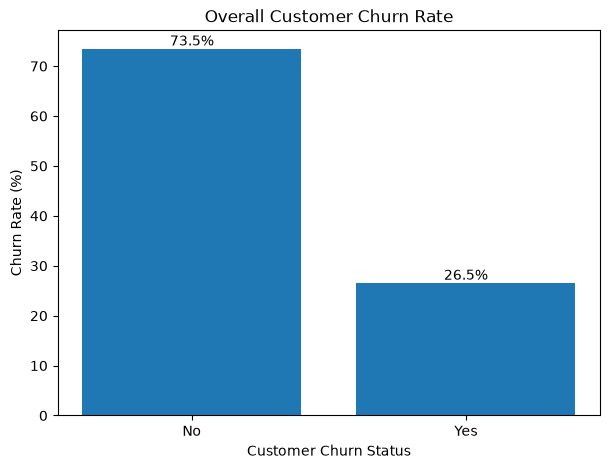

In [89]:
# Overall Customer Churn Rate

churn_counts = customer_data['churn_label'].value_counts()
churn_pct = customer_data['churn_label'].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))

bars = plt.bar(churn_counts.index, churn_pct)

plt.title('Overall Customer Churn Rate')
plt.xlabel('Customer Churn Status')
plt.ylabel('Churn Rate (%)')

for bar, pct in zip(bars, churn_pct):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{pct:.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

In [90]:
# Inspect the customer-characteristic columns distributions
customer_data[
    [
        'age',
        'gender',
        'under_30',
        'senior_citizen',
        'married',
        'dependents',
        'number_of_dependents',
        'referred_a_friend',
        'number_of_referrals'
    ]
].describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,7043.0,NaN,NaN,NaN,46.509726,16.750352,19.0,32.0,46.0,60.0,80.0
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
under_30,7043,2,No,5642,NaN,NaN,NaN,NaN,NaN,NaN,NaN
senior_citizen,7043,2,No,5901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
married,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dependents,7043,2,No,5416,NaN,NaN,NaN,NaN,NaN,NaN,NaN
number_of_dependents,7043.0,NaN,NaN,NaN,0.468692,0.962802,0.0,0.0,0.0,0.0,9.0
referred_a_friend,7043,2,No,3821,NaN,NaN,NaN,NaN,NaN,NaN,NaN
number_of_referrals,7043.0,NaN,NaN,NaN,1.951867,3.001199,0.0,0.0,0.0,3.0,11.0


In [91]:
# Create age groups
customer_data['age_group'] = pd.cut(
    customer_data['age'],
    bins=[18, 29, 44, 59, 80],
    labels=[
        '18-29',
        '30-44',
        '45-59',
        '60+'
    ]
)

age_group_counts = (
    customer_data['age_group']
    .value_counts()
    .sort_index()
)

age_group_counts

age_group
18-29    1401
30-44    1943
45-59    1917
60+      1782
Name: count, dtype: int64

In [92]:
# Calculate churn rate
age_group_churn = (
    customer_data
    .groupby('age_group', observed=False)['churn_label']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='churn_rate')
)

age_group_churn

,age_group,churn_rate
0,18-29,21.698787
1,30-44,24.446732
2,45-59,23.943662
3,60+,35.409652


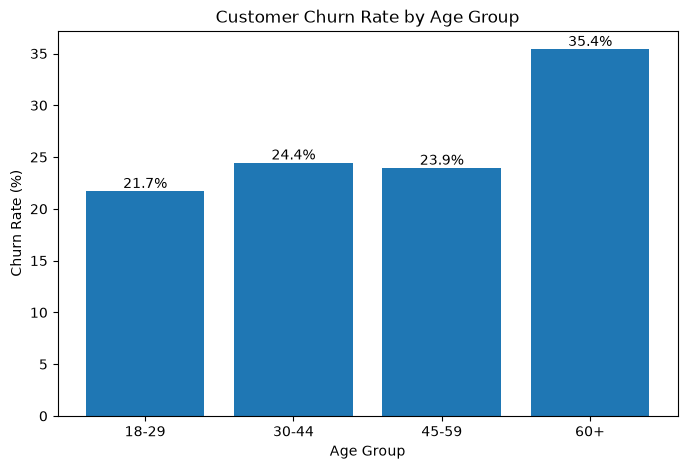

In [93]:
# Customer Churn Rate by Age Group

plt.figure(figsize=(8, 5))

bars = plt.bar(
    age_group_churn['age_group'].astype(str),
    age_group_churn['churn_rate']
)

plt.title('Customer Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')

for bar, rate in zip(bars, age_group_churn['churn_rate']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{rate:.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

In [94]:
customer_characteristics = [
    'gender',
    'married',
    'dependents',
    'referred_a_friend'
]

for column in customer_characteristics:
    result = (
        customer_data
        .groupby(column)['churn_label']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .round(2)
    )
    
    print(f'\n{column}')
    print(result)


gender
gender
Female    26.92
Male      26.16
Name: churn_label, dtype: float64

married
married
No     32.96
Yes    19.66
Name: churn_label, dtype: float64

dependents
dependents
No     32.55
Yes     6.52
Name: churn_label, dtype: float64

referred_a_friend
referred_a_friend
No     32.58
Yes    19.37
Name: churn_label, dtype: float64


In [95]:
# Summarize how many services each customer uses
service_columns = [
    'phone_service',
    'multiple_lines',
    'online_security',
    'online_backup',
    'device_protection_plan',
    'premium_tech_support',
    'streaming_tv',
    'streaming_movies',
    'streaming_music'
]

customer_data['service_count'] = (
    customer_data[service_columns]
    .apply(lambda row: (row == 'Yes').sum(), axis=1)
)

customer_data[['customer_id', 'service_count', 'churn_label']].head()

,customer_id,service_count,churn_label
0,8779-QRDMV,2,Yes
1,7495-OOKFY,3,Yes
2,1658-BYGOY,5,Yes
3,4598-XLKNJ,5,Yes
4,4846-WHAFZ,2,Yes


In [96]:
# Check how churn changes as a service count changes
service_count_churn = (
    customer_data
    .groupby('service_count')['churn_label']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='churn_rate')
)

service_count_churn

,service_count,churn_rate
0,0,43.835616
1,1,19.724221
2,2,31.452359
3,3,35.881628
4,4,34.732824
5,5,31.257942
6,6,25.067024
7,7,21.684588
8,8,11.781609
9,9,4.864865


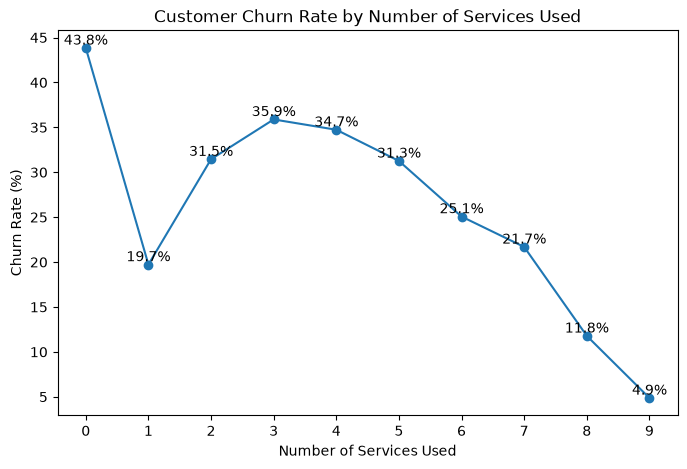

In [97]:
# Customer Churn Rate by Number of Services Used
plt.figure(figsize=(8, 5))

plt.plot(
    service_count_churn['service_count'],
    service_count_churn['churn_rate'],
    marker='o'
)

plt.title('Customer Churn Rate by Number of Services Used')
plt.xlabel('Number of Services Used')
plt.ylabel('Churn Rate (%)')

plt.xticks(service_count_churn['service_count'])

for x, y in zip(
    service_count_churn['service_count'],
    service_count_churn['churn_rate']
):
    plt.text(
        x,
        y,
        f'{y:.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

In [98]:
# Inspect tenure
customer_data['tenure_in_months'].describe()

count    7043.000000
mean       32.386767
std        24.542061
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure_in_months, dtype: float64

In [99]:
# Create tenure groups
customer_data['tenure_group'] = pd.cut(
    customer_data['tenure_in_months'],
    bins=[0, 6, 12, 24, 36, 48, 60, 72],
    labels=[
        '1–6 months',
        '7–12 months',
        '13–24 months',
        '25–36 months',
        '37–48 months',
        '49–60 months',
        '61–72 months'
    ]
)

customer_data['tenure_group'].value_counts().sort_index()

tenure_group
1–6 months      1470
7–12 months      716
13–24 months    1024
25–36 months     832
37–48 months     762
49–60 months     832
61–72 months    1407
Name: count, dtype: int64

In [100]:
# calculate churn rate for each tenure groups
tenure_churn = (
    customer_data
    .groupby('tenure_group', observed=False)['churn_label']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='churn_rate')
)

tenure_churn

,tenure_group,churn_rate
0,1–6 months,53.333333
1,7–12 months,35.335196
2,13–24 months,28.710938
3,25–36 months,21.634615
4,37–48 months,19.028871
5,49–60 months,14.423077
6,61–72 months,6.609808


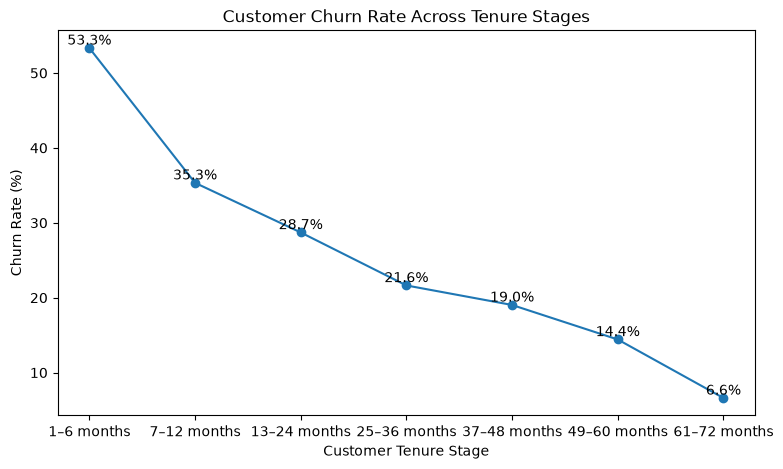

In [101]:
# Customer Churn Rate Across Tenure Stages

plt.figure(figsize=(9, 5))

plt.plot(
    tenure_churn['tenure_group'].astype(str),
    tenure_churn['churn_rate'],
    marker='o'
)

plt.title('Customer Churn Rate Across Tenure Stages')
plt.xlabel('Customer Tenure Stage')
plt.ylabel('Churn Rate (%)')

for x, y in zip(
    tenure_churn['tenure_group'].astype(str),
    tenure_churn['churn_rate']
):
    plt.text(
        x,
        y,
        f'{y:.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

In [102]:
# Calculate churn by tenure group and contract type
tenure_contract_churn = (
    customer_data
    .groupby(['tenure_group', 'contract'], observed=False)['churn_label']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='churn_rate')
)

tenure_contract_churn

,tenure_group,contract,churn_rate
0,1–6 months,Month-to-Month,57.059254
1,1–6 months,One Year,7.692308
2,1–6 months,Two Year,0.000000
3,7–12 months,Month-to-Month,44.688645
4,7–12 months,One Year,9.574468
5,7–12 months,Two Year,0.000000
6,13–24 months,Month-to-Month,40.524781
7,13–24 months,One Year,7.441860
8,13–24 months,Two Year,0.000000
9,25–36 months,Month-to-Month,36.489607


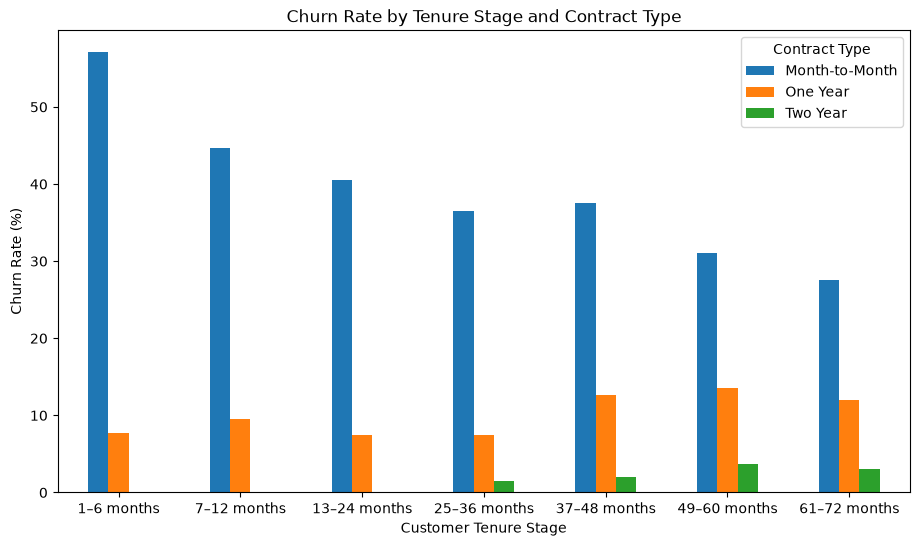

In [103]:
# Churn rate by tenure groups and contract type
chart_data = tenure_contract_churn.pivot(
    index='tenure_group',
    columns='contract',
    values='churn_rate'
)

ax = chart_data.plot(
    kind='bar',
    figsize=(11, 6)
)

plt.title('Churn Rate by Tenure Stage and Contract Type')
plt.xlabel('Customer Tenure Stage')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=0)
plt.legend(title='Contract Type')

plt.show()

Exploratory Findings
1. Overall churn: 26.5% of customers have churned, establishing the baseline churn rate.
2. Customer characteristics: Customers without dependents, unmarried customers, and customers who had not referred a friend showed higher observed churn rates than their respective comparison groups.
3. Service engagement: Customers with higher service counts generally showed lower observed churn, although the relationship was not perfectly consistent at every service-count level.
4. Customer lifecycle: Churn was highest among customers in the earliest tenure stage (1–6 months) and progressively lower across longer tenure stages.
5. Tenure and contract: Month-to-Month customers showed the highest observed churn across every tenure stage, while Two Year customers showed the lowest observed churn rates.

In [104]:
eda_columns = [
    'age_group',
    'service_count',
    'tenure_group'
]

customer_data_base = customer_data.drop(columns=eda_columns)

customer_data_base.to_csv(
    'telco_customer_churn_final.csv',
    index=False
)